# Random Walks

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from IPython.display import display

## Simulation

In [2]:
def randomwalk1d(n_steps, step_size = 1, p = 1/2):
    """Generates the positions of a 1D random walk

    Args:
        n_steps (int): number of steps
        step_size (int, optional):  Defaults to 1.

    Returns:
        ndarray: position of the random walker at each time step
    """
    # generate a list of steps
    directions = np.random.choice([-1,1], p = [1-p,p], size = n_steps)
    u = step_size*directions
    # generate positions for each time step
    positions = np.cumsum(u)
    # insert the initial position
    positions = np.insert(positions, 0, 0)
    return positions

### Running the simulation

In [3]:
positions = randomwalk1d(n_steps=500, step_size=1)

## Measurements

### Single Trajectory

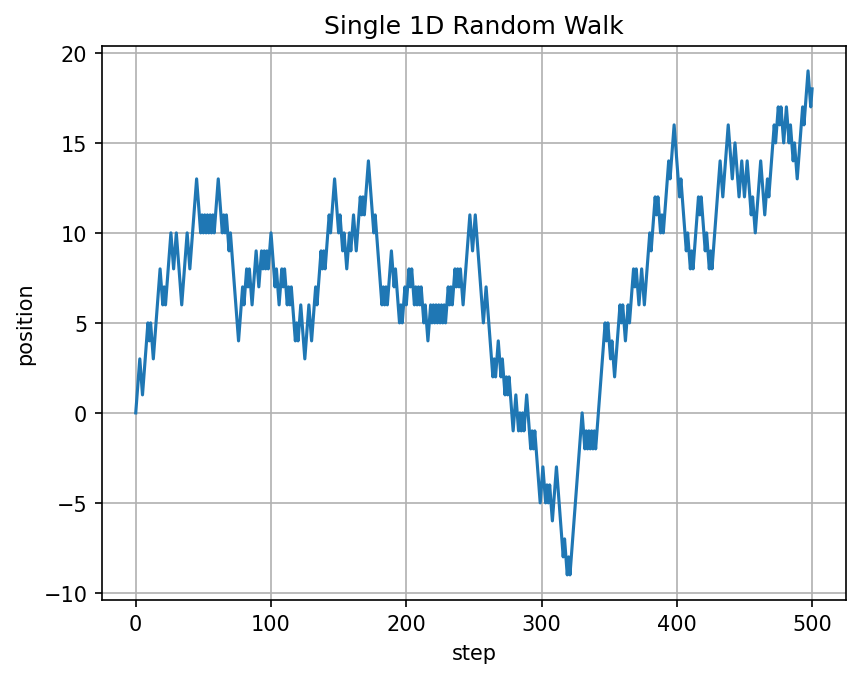

In [4]:
fig, ax = plt.subplots(dpi=150)
ax.plot(positions)
ax.set_title("Single 1D Random Walk")
ax.set_ylabel("position")
ax.set_xlabel("step")
ax.grid()

### Ensemble of Trajectories

Text(0, 0.5, 'Position')

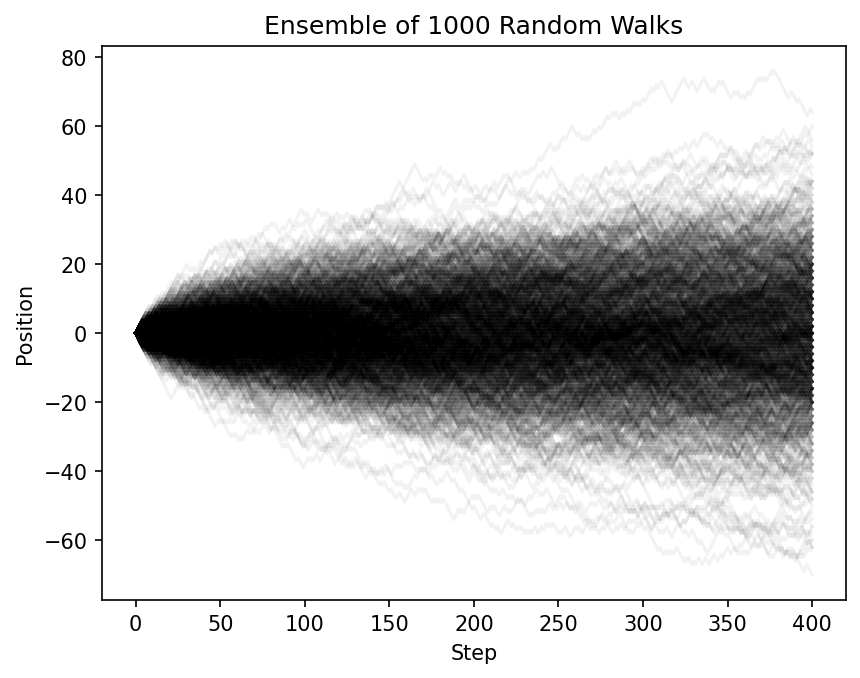

In [5]:
# create an ensemble of 1000 trajectories
n_trajs = 1000
walks = np.asarray([randomwalk1d(n_steps=400) for i in range(n_trajs)])
# plot all of the trajectories on one set of axes
fig, ax = plt.subplots(dpi=150)
for walk in walks:
    ax.plot(walk, color="black", alpha=0.05)
ax.set_title(f"Ensemble of {n_trajs} Random Walks")
ax.set_xlabel("Step")
ax.set_ylabel("Position")

### Standard Deviation of an Ensemble of Trajectories

In [6]:
# to obtain the exponent numerically, we import a nonlinear regression function
from scipy.optimize import curve_fit

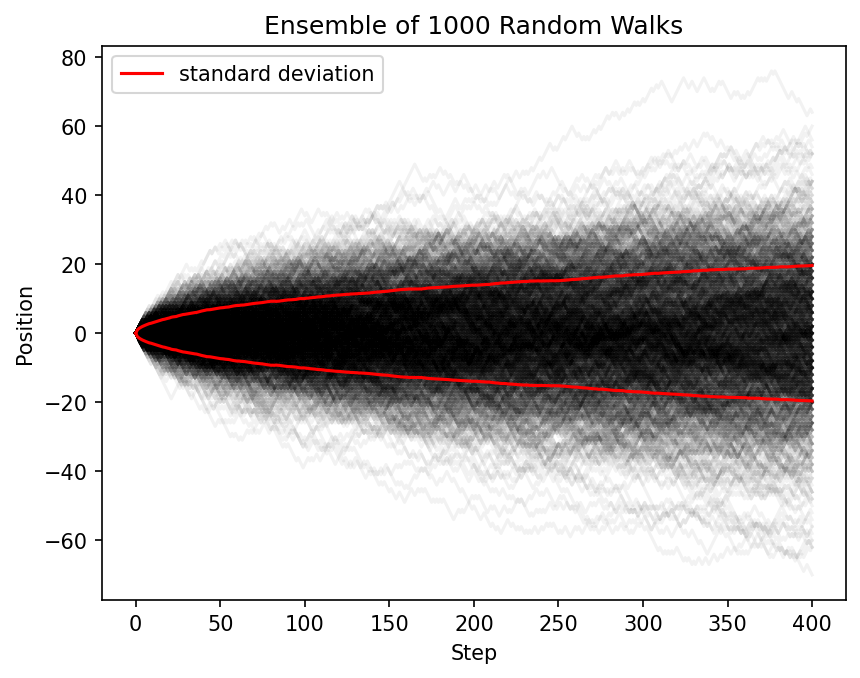

In [7]:
# calculate the standard deviation of the ensemble at each time step
std_series = np.std(walks, axis=0)
# plot the standard deviation on top of the ensemble
ax.plot(std_series, color = "red", label="standard deviation")
ax.plot(-std_series, color = "red")
ax.legend()
display(fig)

In [8]:
# nonlinear regression fit
Ns = np.arange(401)
def power_law(N, c, alpha):
    return c*N**alpha

In [13]:
params, _ = curve_fit(power_law, Ns, std_series)
alpha = params[1]
print(f"alpha = {alpha}")

alpha = 0.48262211164219126


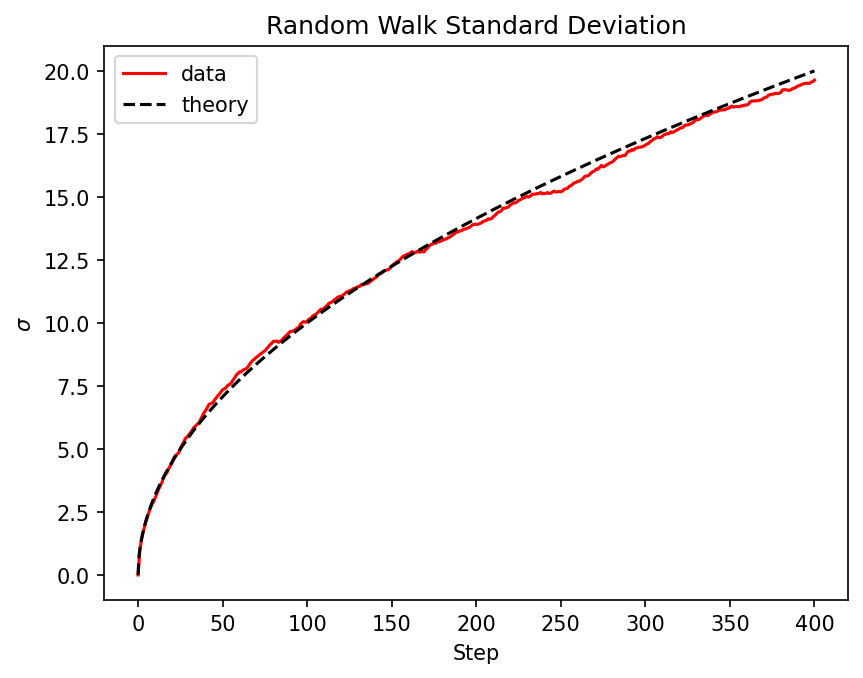

In [19]:
fig, ax = plt.subplots(dpi=150)
x_vals = np.linspace(0,400,1000)
theory_std = power_law(x_vals, 1, 1/2)
ax.plot(Ns, std_series, color="red", label="data")
ax.plot(x_vals, theory_std, ls="--", color="black", label="theory")
ax.set_title("Random Walk Standard Deviation")
ax.set_ylabel(r"$\sigma$")
ax.set_xlabel("Step")
ax.legend()

### Convergence to Normal Distribution by Central Limit Theorem

In [ ]:
# import scipy to fit the data to a normal (Gaussian) distribution
from scipy.stats import norm

In [328]:
# generate a large ensemble of trajectories with many steps
n_trajs = 50000
n_steps = 10000
# save only the final position of each walker
final_positions = [randomwalk1d(n_steps)[-1] for _ in range(n_trajs)]

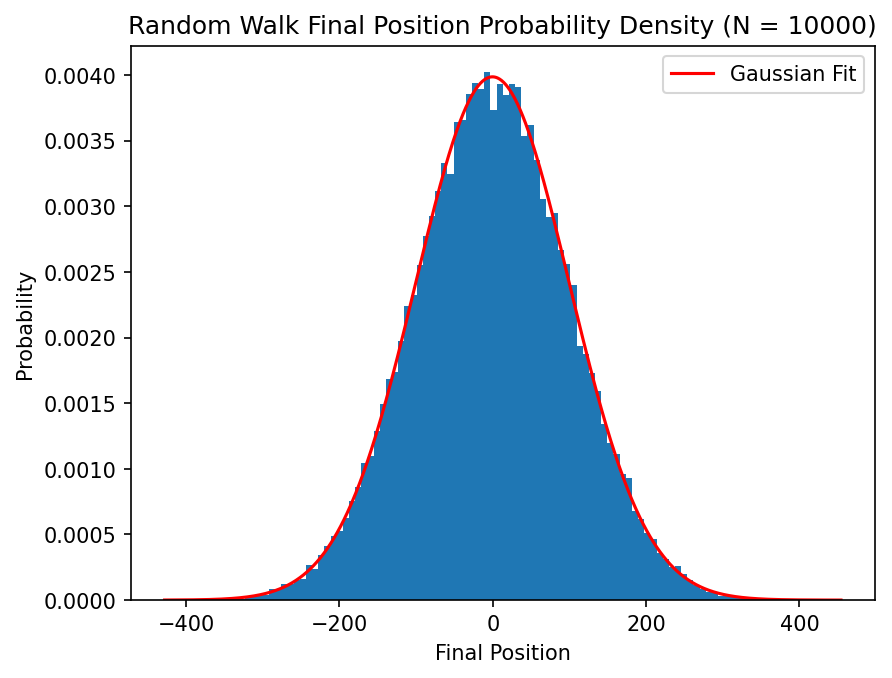

In [329]:
# plot the histogram of final positions
fig, ax = plt.subplots(dpi=150)
ax.hist(final_positions, bins = 100 , density=True)     # density = True normalizes the histogram
# fit the data
mu, std = norm.fit(final_positions)     # returns the estimated parameters of the Gaussian fit
# obtain the range of x-values from the plot
xmin, xmax = ax.get_xlim()
xvals = np.linspace(xmin, xmax, 1000)
# plot the fit
gauss_fit = norm.pdf(xvals, loc=mu, scale=std)
ax.plot(xvals, gauss_fit, color="red", label="Gaussian Fit")

ax.set_title(f"Random Walk Final Position Probability Density (N = {n_steps})")
ax.set_xlabel("Final Position")
ax.set_ylabel("Probability")
ax.legend()